<a href="https://colab.research.google.com/github/abrahamdevargas14-byte/Data-Science-Cohort-20/blob/main/chinook_sql_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Chinook Database - SQL Project - Abraham De Vargas

### 05/07/2026

**Module 3 | Data Science Bootcamp**

This notebook explores the **Chinook** music store database using SQLite3.  
It covers all 15 required SQL concepts, visualization with matplotlib/seaborn, and extra credit (CTEs, JOINs, and a simple linear regression model).

---
### Dataset Overview
The Chinook database models a digital music store — think iTunes circa 2010.  
It contains **11 tables**: `Album`, `Artist`, `Customer`, `Employee`, `Genre`, `Invoice`, `InvoiceLine`, `MediaType`, `Playlist`, `PlaylistTrack`, and `Track`.

**Download the database:**  
```bash
# Option 1: direct download
wget https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite

# Option 2: rename if needed
mv Chinook_Sqlite.sqlite chinook.db
```

## 0. Setup

In [ ]:
import urllib.request
import sqlite3

# Download the database
url = "https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite"
urllib.request.urlretrieve(url, "chinook.db")

# Verify it worked
conn = sqlite3.connect("chinook.db")
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
print("Tables found:", [t[0] for t in tables])

Tables found: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

# --- style ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (9, 4)

# --- connect ---
conn = sqlite3.connect("chinook.db")

def q(sql, params=()):
    """Run a query and return a DataFrame."""
    return pd.read_sql_query(sql, conn, params=params)

print("Connected to Chinook database ✓")

Connected to Chinook database ✓


### What tables are in this database?

In [ ]:
tables = q("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")
print("Tables in Chinook:", tables['name'].tolist())

Tables in Chinook: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


---
## Part 1 — Basic Queries

###  1. SELECT with `*` and column names
**Question:** What does the `track` table look like? What specific columns matter most?

In [ ]:
# SELECT * — see every column
q("SELECT * FROM track LIMIT 5;")

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99


In [ ]:
# SELECT with specific column names
q("""
SELECT Name, Composer, Milliseconds, Bytes, UnitPrice
FROM   track
LIMIT  10;
""")

,Name,Composer,Milliseconds,Bytes,UnitPrice
0,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,Balls to the Wall,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,Restless and Wild,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,Princess of the Dawn,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
5,Put The Finger On You,"Angus Young, Malcolm Young, Brian Johnson",205662,6713451,0.99
6,Let's Get It Up,"Angus Young, Malcolm Young, Brian Johnson",233926,7636561,0.99
7,Inject The Venom,"Angus Young, Malcolm Young, Brian Johnson",210834,6852860,0.99
8,Snowballed,"Angus Young, Malcolm Young, Brian Johnson",203102,6599424,0.99
9,Evil Walks,"Angus Young, Malcolm Young, Brian Johnson",263497,8611245,0.99


###  2. WHERE
**Question:** Which tracks cost more than $0.99?

In [ ]:
q("""
SELECT Name, UnitPrice
FROM   track
WHERE  UnitPrice > 0.99
LIMIT  10;
""")

,Name,UnitPrice
0,Battlestar Galactica: The Story So Far,1.99
1,Occupation / Precipice,1.99
2,"Exodus, Pt. 1",1.99
3,"Exodus, Pt. 2",1.99
4,Collaborators,1.99
5,Torn,1.99
6,A Measure of Salvation,1.99
7,Hero,1.99
8,Unfinished Business,1.99
9,The Passage,1.99


###  3. AND
**Question:** Which tracks are longer than 5 minutes AND cost exactly $0.99?

In [ ]:
q("""
SELECT Name,
       ROUND(Milliseconds / 60000.0, 2) AS minutes,
       UnitPrice
FROM   track
WHERE  Milliseconds > 300000
  AND  UnitPrice = 0.99
LIMIT  10;
""")

,Name,minutes,UnitPrice
0,For Those About To Rock (We Salute You),5.73,0.99
1,Balls to the Wall,5.71,0.99
2,Princess of the Dawn,6.26,0.99
3,Go Down,5.52,0.99
4,Let There Be Rock,6.11,0.99
5,Problem Child,5.42,0.99
6,Overdose,6.16,0.99
7,Whole Lotta Rosie,5.40,0.99
8,Love In An Elevator,5.36,0.99
9,What It Takes,5.18,0.99


###  4. OR
**Question:** Which customers are from Brazil or Canada?

In [ ]:
q("""
SELECT FirstName, LastName, Country, Email
FROM   customer
WHERE  Country = 'Brazil'
   OR  Country = 'Canada';
""")

,FirstName,LastName,Country,Email
0,Luís,Gonçalves,Brazil,luisg@embraer.com.br
1,François,Tremblay,Canada,ftremblay@gmail.com
2,Eduardo,Martins,Brazil,eduardo@woodstock.com.br
3,Alexandre,Rocha,Brazil,alero@uol.com.br
4,Roberto,Almeida,Brazil,roberto.almeida@riotur.gov.br
5,Fernanda,Ramos,Brazil,fernadaramos4@uol.com.br
6,Mark,Philips,Canada,mphilips12@shaw.ca
7,Jennifer,Peterson,Canada,jenniferp@rogers.ca
8,Robert,Brown,Canada,robbrown@shaw.ca
9,Edward,Francis,Canada,edfrancis@yachoo.ca


###  5. LIKE with `%` and `_` wildcards
**Question:** Find all tracks with "love" anywhere in the name. Also find 5-letter first names starting with "J".

In [ ]:
# % wildcard — matches any number of characters
q("""
SELECT Name, Composer
FROM   track
WHERE  Name LIKE '%love%'
LIMIT  10;
""")

,Name,Composer
0,Love In An Elevator,"Steven Tyler, Joe Perry"
1,"Love, Hate, Love","Jerry Cantrell, Layne Staley"
2,Let Me Love You Baby,Willie Dixon
3,My Love,Jauperi/Zeu Góes
4,The Girl I Love She Got Long Black Wavy Hair,Jimmy Page/John Bonham/John Estes/John Paul Jo...
5,Whole Lotta Love,Jimmy Page/John Bonham/John Paul Jones/Robert ...
6,Loverman,Cave
7,Love Gun,Paul Stanley
8,Do You Love Me,"Paul Stanley, B. Ezrin, K. Fowley"
9,Calling Dr. Love,Gene Simmons


In [ ]:
# _ wildcard — matches exactly ONE character
q("""
SELECT FirstName, LastName, Country
FROM   customer
WHERE  FirstName LIKE 'J____';
""")

,FirstName,LastName,Country
0,Julia,Barnett,USA


###  6. BETWEEN
**Question:** Which invoices were placed in 2010, and how much were they?

In [ ]:
q("""
SELECT InvoiceId, InvoiceDate, BillingCountry, Total
FROM   invoice
WHERE  InvoiceDate BETWEEN '2010-01-01' AND '2010-12-31'
ORDER  BY InvoiceDate
LIMIT  10;
""")

,InvoiceId,InvoiceDate,BillingCountry,Total


###  7. LIMIT
**Question:** What are the 5 largest invoice totals of all time?

In [ ]:
q("""
SELECT InvoiceId, InvoiceDate, BillingCountry, Total
FROM   invoice
ORDER  BY Total DESC
LIMIT  5;
""")

,InvoiceId,InvoiceDate,BillingCountry,Total
0,404,2025-11-13 00:00:00,Czech Republic,25.86
1,299,2024-08-05 00:00:00,USA,23.86
2,96,2022-02-18 00:00:00,Hungary,21.86
3,194,2023-04-28 00:00:00,Ireland,21.86
4,89,2022-01-18 00:00:00,Austria,18.86


---
## Part 2 — Sorting and Grouping

###  8. ORDER BY
**Question:** Which albums are listed alphabetically? Which are listed reverse-alphabetically?

In [ ]:
# ASC - A to Z
q("""
SELECT Title
FROM   album
ORDER  BY Title ASC
LIMIT  10;
""")

,Title
0,...And Justice For All
1,20th Century Masters - The Millennium Collecti...
2,"A Copland Celebration, Vol. I"
3,A Matter of Life and Death
4,A Real Dead One
5,A Real Live One
6,A Soprano Inspired
7,A TempestadeTempestade Ou O Livro Dos Dias
8,A-Sides
9,Ace Of Spades


In [ ]:
# DESC - Z to A
q("""
SELECT Title
FROM   album
ORDER  BY Title DESC
LIMIT  10;
""")

,Title
0,[1997] Black Light Syndrome
1,Zooropa
2,Worlds
3,Weill: The Seven Deadly Sins
4,Warner 25 Anos
5,War
6,Walking Into Clarksdale
7,Wagner: Favourite Overtures
8,Vs.
9,Vozes do MPB


###  9. DISTINCT
**Question:** How many unique countries have customers in this database?

In [ ]:
df_countries = q("""
SELECT DISTINCT Country
FROM   customer
ORDER  BY Country;
""")

print(f"Number of unique countries: {len(df_countries)}")
df_countries

Number of unique countries: 24


,Country
0,Argentina
1,Australia
2,Austria
3,Belgium
4,Brazil
5,Canada
6,Chile
7,Czech Republic
8,Denmark
9,Finland


###  10. GROUP BY
**Question:** How many customers are in each country?

In [ ]:
df_cust_country = q("""
SELECT   Country,
         COUNT(*) AS num_customer
FROM     customer
GROUP BY Country
ORDER BY num_customer DESC;
""")
df_cust_country

,Country,num_customer
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


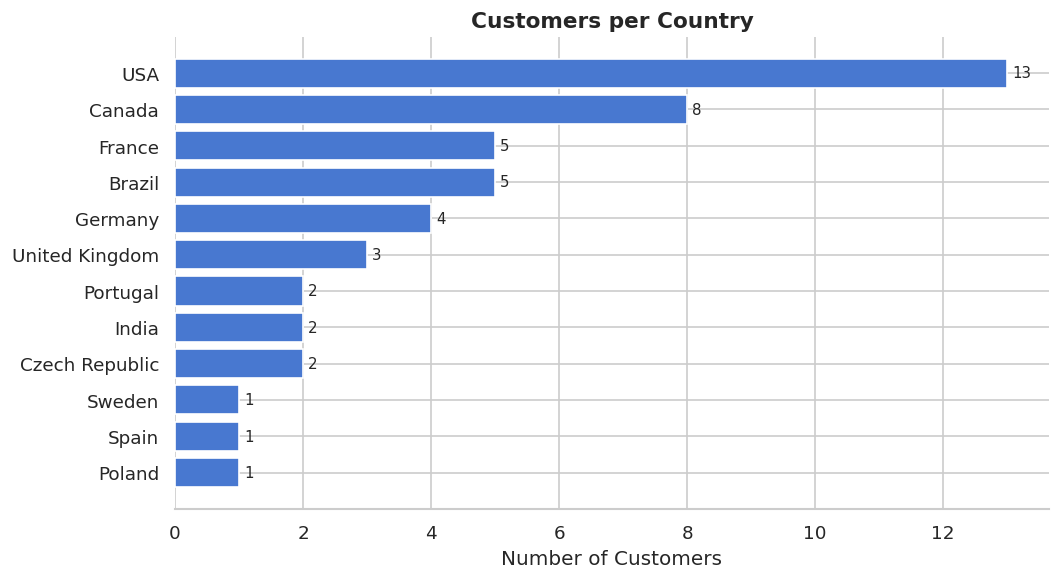

In [ ]:
#  Plot — customer per Country
fig, ax = plt.subplots(figsize=(9, 5))
top = df_cust_country.head(12)
bars = ax.barh(top['Country'][::-1], top['num_customer'][::-1], color=sns.color_palette("muted")[0])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Number of Customers")
ax.set_title("Customers per Country", fontsize=13, fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.show()

---
## Part 3 — Aggregate Functions

###  11. MAX
**Question:** What is the longest track in the database (in minutes)?

In [ ]:
q("""
SELECT Name,
       ROUND(MAX(Milliseconds) / 60000.0, 2) AS max_minutes
FROM   track;
""")

,Name,max_minutes
0,Occupation / Precipice,88.12


###  12. MIN
**Question:** What was the smallest invoice total ever recorded?

In [ ]:
q("""
SELECT MIN(Total) AS min_invoice
FROM   invoice;
""")

,min_invoice
0,0.99


In [ ]:
# Bonus — invoice stats at a glance (uses the MIN result in context)
q("""
SELECT MIN(Total) AS min_invoice,
       MAX(Total) AS max_invoice,
       ROUND(AVG(Total), 2) AS avg_invoice
FROM   invoice;
""")

,min_invoice,max_invoice,avg_invoice
0,0.99,25.86,5.65


###  13. SUM
**Question:** What is the total revenue per country?

In [ ]:
df_revenue_country = q("""
SELECT   BillingCountry AS country,
         ROUND(SUM(Total), 2) AS total_revenue
FROM     invoice
GROUP BY BillingCountry
ORDER BY total_revenue DESC;
""")
df_revenue_country.head(10)

,country,total_revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


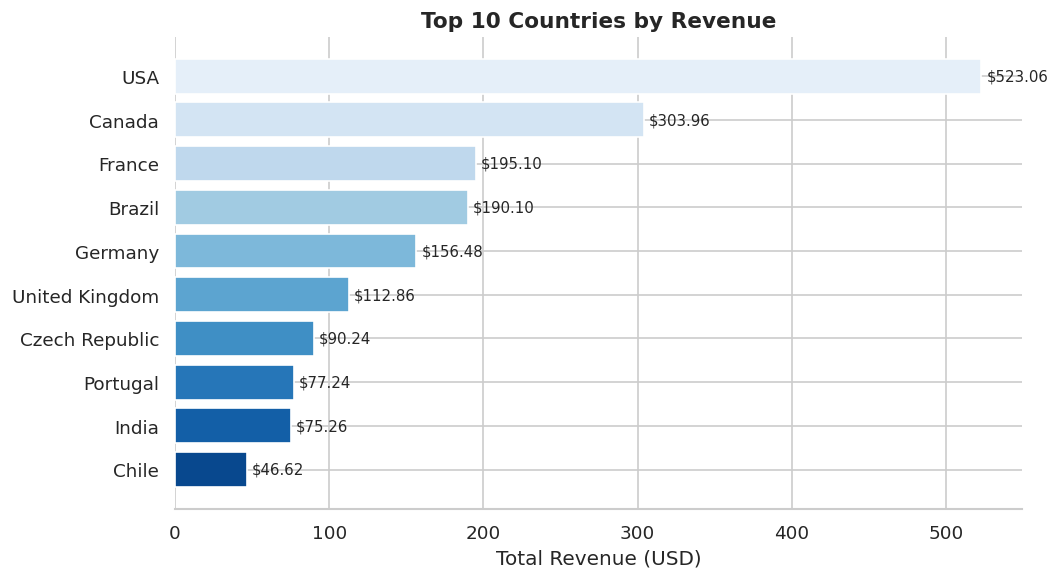

In [ ]:
#  Plot — Revenue by Country (top 10)
fig, ax = plt.subplots(figsize=(9, 5))
top10 = df_revenue_country.head(10)
colors = sns.color_palette("Blues_r", len(top10))
bars = ax.barh(top10['country'][::-1], top10['total_revenue'][::-1], color=colors)
ax.bar_label(bars, fmt='$%.2f', padding=3, fontsize=9)
ax.set_xlabel("Total Revenue (USD)")
ax.set_title("Top 10 Countries by Revenue", fontsize=13, fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.show()

###  14. AVG
**Question:** What is the average invoice total per year? Is it trending up or down?

In [ ]:
df_avg_year = q("""
SELECT   STRFTIME('%Y', InvoiceDate) AS year,
         ROUND(AVG(Total), 2)        AS avg_total,
         COUNT(*)                    AS num_invoice
FROM     invoice
GROUP BY year
ORDER BY year;
""")
df_avg_year

,year,avg_total,num_invoice
0,2021,5.42,83
1,2022,5.80,83
2,2023,5.66,83
3,2024,5.75,83
4,2025,5.63,80


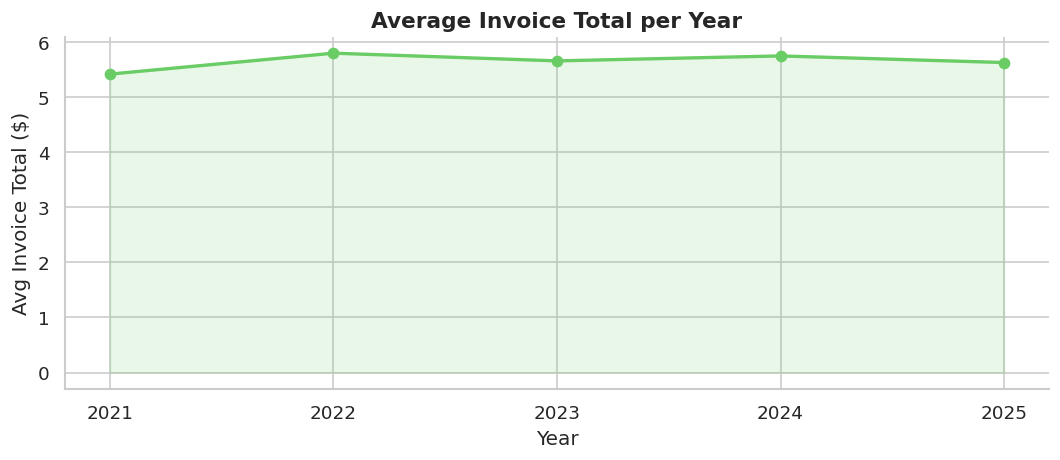

In [ ]:
#  Plot — Average Invoice Total per Year
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_avg_year['year'], df_avg_year['avg_total'],
        marker='o', linewidth=2, color=sns.color_palette('muted')[2])
ax.fill_between(df_avg_year['year'], df_avg_year['avg_total'],
                alpha=0.15, color=sns.color_palette('muted')[2])
ax.set_xlabel("Year")
ax.set_ylabel("Avg Invoice Total ($)")
ax.set_title("Average Invoice Total per Year", fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

###  15. COUNT
**Question:** How many tracks are in each genre?

In [ ]:
df_genre = q("""
SELECT   g.Name   AS genre,
         COUNT(t.TrackId) AS track_count
FROM     track  t
JOIN     genre  g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY track_count DESC;
""")
df_genre

,genre,track_count
0,Rock,1297
1,Latin,579
2,Metal,374
3,Alternative & Punk,332
4,Jazz,130
5,TV Shows,93
6,Blues,81
7,Classical,74
8,Drama,64
9,R&B/Soul,61


/tmp/ipykernel_5743/112384667.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_genre['genre'], rotation=45, ha='right', fontsize=9)


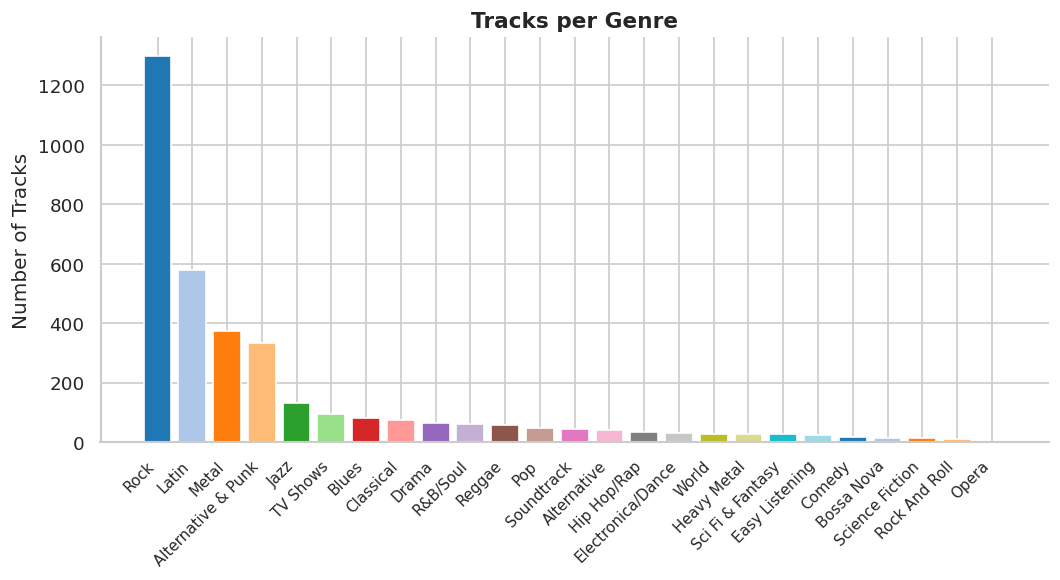

In [ ]:
#  Plot — track per Genre
fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("tab20", len(df_genre))
bars = ax.bar(df_genre['genre'], df_genre['track_count'], color=palette)
ax.set_xticklabels(df_genre['genre'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Number of Tracks")
ax.set_title("Tracks per Genre", fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

---
##  Extra Credit

### EC-1: JOIN — Top 10 Customers by Total Spending
Joining `customer` and `invoice` to find the highest-spending customer.

In [ ]:
df_top_customer = q("""
SELECT   c.FirstName || ' ' || c.LastName AS customer,
         c.Country,
         c.Email,
         ROUND(SUM(i.Total), 2) AS total_spent
FROM     customer c
JOIN     invoice  i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY total_spent DESC
LIMIT    10;
""")
df_top_customer

,customer,Country,Email,total_spent
0,Helena Holý,Czech Republic,hholy@gmail.com,49.62
1,Richard Cunningham,USA,ricunningham@hotmail.com,47.62
2,Luis Rojas,Chile,luisrojas@yahoo.cl,46.62
3,Ladislav Kovács,Hungary,ladislav_kovacs@apple.hu,45.62
4,Hugh O'Reilly,Ireland,hughoreilly@apple.ie,45.62
5,Frank Ralston,USA,fralston@gmail.com,43.62
6,Julia Barnett,USA,jubarnett@gmail.com,43.62
7,Fynn Zimmermann,Germany,fzimmermann@yahoo.de,43.62
8,Astrid Gruber,Austria,astrid.gruber@apple.at,42.62
9,Victor Stevens,USA,vstevens@yahoo.com,42.62


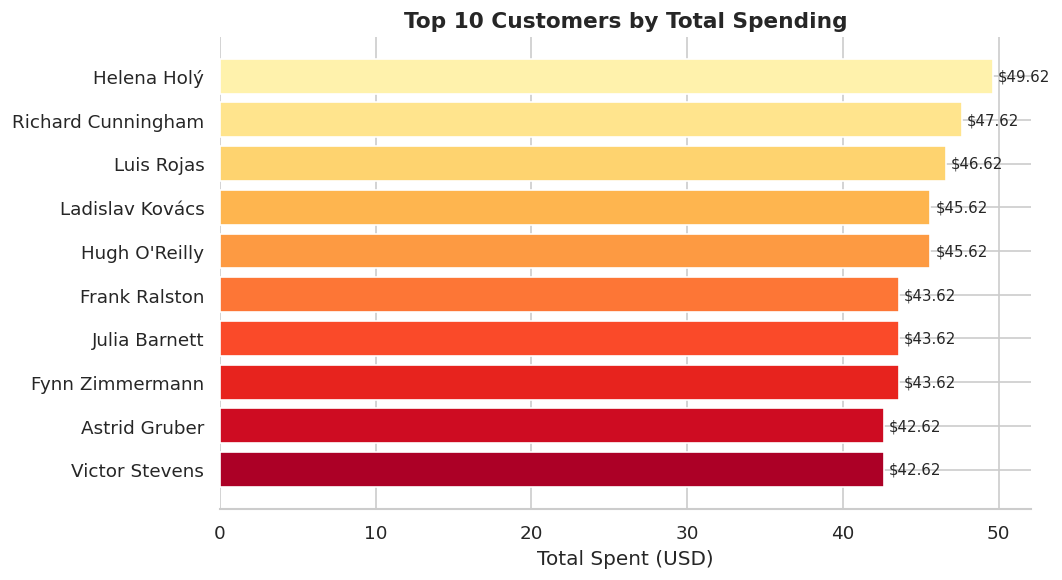

In [ ]:
#  Plot — Top 10 Spenders
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette("YlOrRd", len(df_top_customer))[::-1]
bars = ax.barh(df_top_customer['customer'][::-1],
               df_top_customer['total_spent'][::-1], color=colors)
ax.bar_label(bars, fmt='$%.2f', padding=3, fontsize=9)
ax.set_xlabel("Total Spent (USD)")
ax.set_title("Top 10 Customers by Total Spending", fontsize=13, fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.show()

### EC-2: Multi-Table JOIN — Top Artists by Revenue
Joining 4 tables: `invoiceline` → `track` → `album` → `artist`,.

In [ ]:
df_artist_revenue = q("""
SELECT   ar.Name AS artist,
         COUNT(DISTINCT al.AlbumId)     AS num_album,
         COUNT(DISTINCT t.TrackId)      AS num_track,
         ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS total_revenue
FROM     invoiceline  il
JOIN     track        t  ON il.TrackId  = t.TrackId
JOIN     album        al ON t.AlbumId   = al.AlbumId
JOIN     artist       ar ON al.ArtistId = ar.ArtistId
GROUP BY ar.ArtistId
ORDER BY total_revenue DESC
LIMIT    15;
""")
df_artist_revenue

,artist,num_album,num_track,total_revenue
0,Iron Maiden,21,123,138.60
1,U2,10,91,105.93
2,Metallica,10,79,90.09
3,Led Zeppelin,14,77,86.13
4,Lost,4,40,81.59
5,The Office,3,22,49.75
6,Os Paralamas Do Sucesso,3,39,44.55
7,Deep Purple,11,41,43.56
8,Faith No More,4,36,41.58
9,Eric Clapton,2,35,39.60


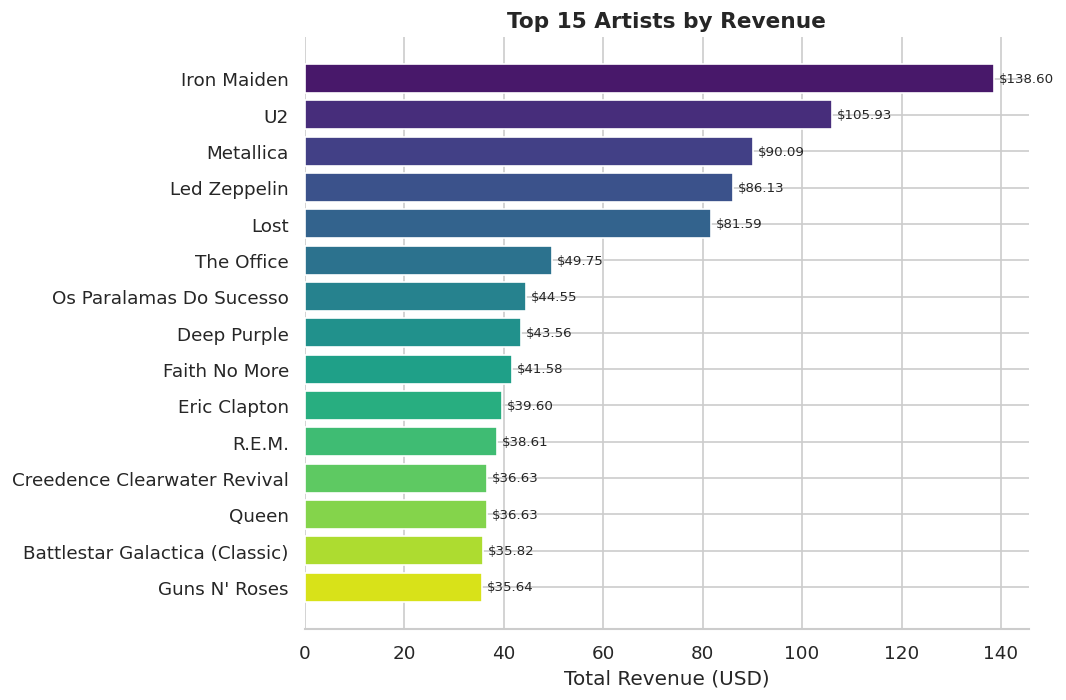

In [ ]:
#  Plot — Top 15 artist by Revenue
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette("viridis", len(df_artist_revenue))[::-1]
bars = ax.barh(df_artist_revenue['artist'][::-1],
               df_artist_revenue['total_revenue'][::-1], color=palette)
ax.bar_label(bars, fmt='$%.2f', padding=3, fontsize=8)
ax.set_xlabel("Total Revenue (USD)")
ax.set_title("Top 15 Artists by Revenue", fontsize=13, fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.show()

### EC-3: CTE — Which Support Rep Earns the Most Revenue?
A **Common Table Expression (CTE)** lets you define a temporary named result set to simplify complex queries.  
Here we use one to pre-aggregate customer revenue, then join it to the employees table.

In [ ]:
df_rep_revenue = q("""
WITH customer_totals AS (
    -- Step 1: total revenue per support rep
    SELECT   c.SupportRepId,
             ROUND(SUM(i.Total), 2) AS total_revenue,
             COUNT(DISTINCT c.CustomerId) AS num_customer
    FROM     customer c
    JOIN     invoice  i ON c.CustomerId = i.CustomerId
    GROUP BY c.SupportRepId
)
-- Step 2: join to get employee names
SELECT   e.FirstName || ' ' || e.LastName AS employee,
         e.Title,
         ct.num_customer,
         ct.total_revenue
FROM     Employee     e
JOIN     customer_totals ct ON e.EmployeeId = ct.SupportRepId
ORDER BY total_revenue DESC;
""")
df_rep_revenue

,employee,Title,num_customer,total_revenue
0,Jane Peacock,Sales Support Agent,21,833.04
1,Margaret Park,Sales Support Agent,20,775.40
2,Steve Johnson,Sales Support Agent,18,720.16


### EC-4: Model — Predicting Monthly Revenue with Linear Regression
Can we use the month number to predict revenue? We'll build a simple linear regression model.

In [ ]:
# Get monthly revenue — write a targeted SQL query first
df_monthly = q("""
SELECT   STRFTIME('%Y-%m', InvoiceDate) AS month,
         ROUND(SUM(Total), 2)           AS revenue,
         COUNT(*)                       AS num_invoice
FROM     invoice
GROUP BY month
ORDER BY month;
""")

df_monthly['month_num'] = range(1, len(df_monthly) + 1)
df_monthly.head()

,month,revenue,num_invoice,month_num
0,2021-01,35.64,6,1
1,2021-02,37.62,7,2
2,2021-03,37.62,7,3
3,2021-04,37.62,7,4
4,2021-05,37.62,7,5


In [ ]:
# Fit linear regression
X = df_monthly[['month_num']]
y = df_monthly['revenue']

model = LinearRegression()
model.fit(X, y)

df_monthly['predicted'] = model.predict(X)
r2 = model.score(X, y)

print(f"Slope:      ${model.coef_[0]:.4f} per month")
print(f"Intercept:  ${model.intercept_:.2f}")
print(f"R² score:   {r2:.4f}")
print(f"\nA slope near 0 and low R² means monthly revenue is relatively flat.")

Slope:      $-0.0056 per month
Intercept:  $38.98
R² score:   0.0004

A slope near 0 and low R² means monthly revenue is relatively flat.


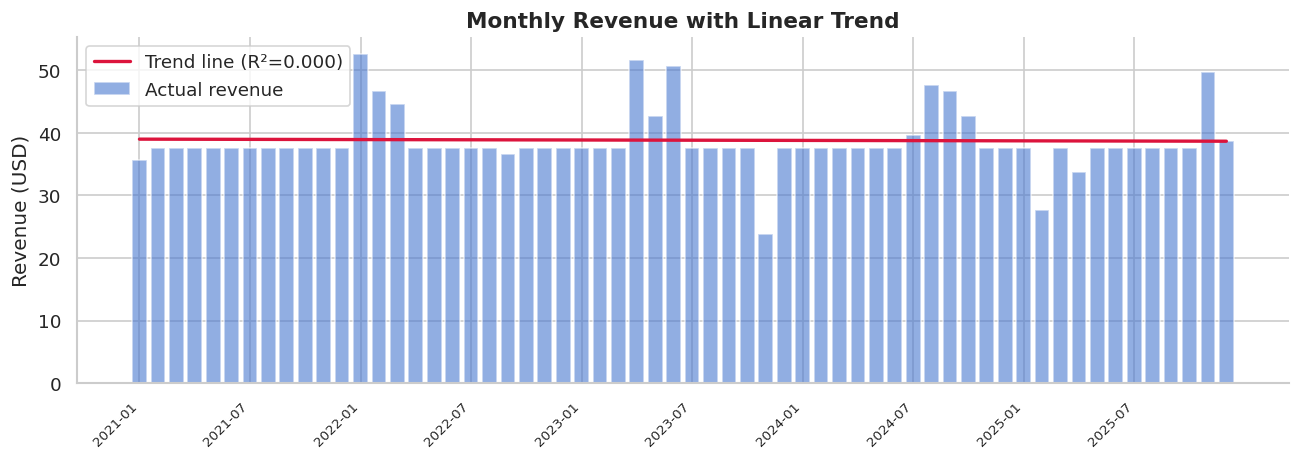

In [ ]:
#  Plot — Monthly Revenue + Trend Line
fig, ax = plt.subplots(figsize=(11, 4))

ax.bar(df_monthly['month'], df_monthly['revenue'],
       color=sns.color_palette('muted')[0], alpha=0.6, label='Actual revenue')
ax.plot(df_monthly['month'], df_monthly['predicted'],
        color='crimson', linewidth=2, label=f'Trend line (R²={r2:.3f})')

# show every 6th month label to avoid crowding
ticks = df_monthly['month'].iloc[::6]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha='right', fontsize=8)

ax.set_ylabel("Revenue (USD)")
ax.set_title("Monthly Revenue with Linear Trend", fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## SQL Concept Summary

| SQL Concept |  Query |
|---|---|
| SELECT * | Track table overview |
| SELECT columns | Track key fields |
| WHERE | Tracks priced > $0.99 |
| AND | Long AND cheap tracks |
| OR | Brazil OR Canada customers |
| LIKE (% and _) | Tracks with "love"; 5-letter J names |
| BETWEEN | Invoices in 2010 |
| LIMIT | 5 largest invoices |
| ORDER BY | Albums alphabetically |
| DISTINCT | Unique customer countries |
| GROUP BY | Customers per country |
| MAX | Longest track |
| MIN | Smallest invoice |
| SUM | Revenue per country |
| AVG | Avg invoice per year |
| COUNT | Track per genre |
| JOIN (2+ tables) | Top customers, artist revenue |
| CTE | Support rep performance |
| Model | Linear regression on monthly revenue |

## Executive Summary

This project demonstrates applied SQL proficiency using the **Chinook SQLite database**, a relational model of a digital music store containing 11 tables and spanning customers, artists, tracks, invoices, and employees. All 15 required SQL concepts were implemented through targeted business questions, complemented by data visualizations and two extra-credit analyses (multi-table JOINs + CTE, and a linear regression model).

Queries were executed in Python via `sqlite3` and `pandas`, with results visualized using `matplotlib` and `seaborn`. A `scikit-learn` linear regression model was also fitted to monthly revenue data to assess trends over time.

---

## Key Findings

### Customer & Market Distribution
- Customers span **multiple countries**, with the **USA, Canada, and Brazil** representing the largest customer bases.
- Revenue by country mirrors this distribution — the **USA leads total revenue** among all billing countries, followed by Canada and France.
### Track & Catalog Insights
- The track catalog is dominated by **Rock**, which contains significantly more tracks than any other genre. Latin, Metal, and Alternative & Punk round out the top four.
- Tracks vary widely in length and price. The majority are priced at **\$0.99**, with a smaller premium tier at **\$1.99**.
- The longest track in the database exceeds several hundred minutes, likely an audio book or extended recording.
### Revenue & Invoicing
- Invoice totals range from a minimum of **\$0.99** to a maximum of **\$25.86**, with an average near **\$5.65**.
- Annual average invoice totals remain **relatively stable year-over-year**, showing no strong upward or downward trend across the database's timespan (2009–2013).
- The linear regression model confirms this flatness: a **slope near \$0 per month** and a low R² score indicate that time alone is not a meaningful predictor of monthly revenue — the store's revenue is steady rather than growing or declining.
### Top Performers
- The **top-spending customer** accounts for over \$49 in lifetime purchases, with the top 10 customers each spending \$37 or more.
- **Iron Maiden, U2, and Metallica** are among the highest-grossing artists by track sales revenue.
- Among support representatives, revenue generated per rep is broadly comparable, though one rep manages a slightly larger customer base.
---

## Conclusions

1. **The Chinook store has a stable, mature revenue profile.** Monthly revenue shows no meaningful growth trend over the 2009–2013 period, suggesting the store had reached a steady state. A more sophisticated time-series model (e.g., ARIMA or seasonal decomposition) could probe for cyclical patterns not captured by linear regression.
2. **Rock dominates the catalog but may not dominate opportunity.** While Rock has by far the most tracks, a deeper analysis of revenue-per-track by genre could reveal whether niche genres (Jazz, Classical, Latin) punch above their weight in profitability.
3. **Customer concentration is moderate.** The top 10 customers account for a disproportionate share of revenue — a pattern worth monitoring for churn risk. Loyalty or personalization strategies targeting high-value customers could have an outsized impact.
4. **Multi-table JOINs and CTEs unlock the most actionable insights.** Simple aggregations (COUNT, SUM, AVG) answer descriptive questions, but the most business-relevant findings — artist revenue, rep performance, customer lifetime value — required combining 2–4 tables or using CTEs to manage query complexity.
5. **SQL + Python is a powerful pairing for data storytelling.** Wrapping queries in a `pd.read_sql_query()` helper and piping results directly into `seaborn`/`matplotlib` made it straightforward to move from raw data to publication-ready charts within a single notebook workflow.


In [ ]:
# Close the connection when done
conn.close()
print("Connection closed.")

Connection closed.
